<a href="https://colab.research.google.com/github/mmm10138/Machine-Learning/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we will see how to perform a regression task using neural networks implemented in Pytorch.

We start with a basic version and then discuss improvements.

# Part 1: Basic version

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Problem setting

We create the true function to be found by the neural network (in practice we do not know this function and we only have the data set).

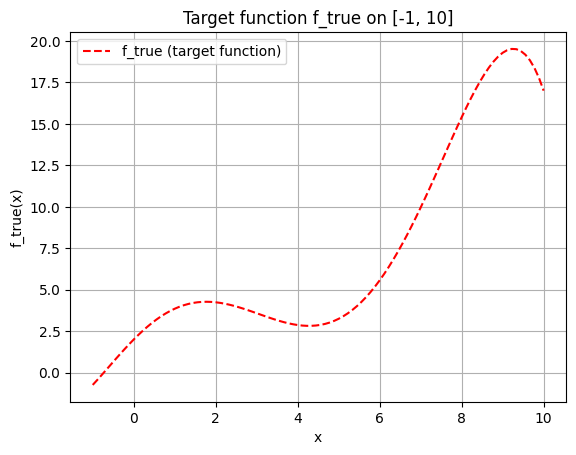

In [ ]:
# Define the target function f_true
def f_true(x):
    return 2 + 2.5*x - 0.5*x**2 - 0.2*x**3 + 0.06*x**4 - 0.0036*x**5

x_plot = np.linspace(-1, 10, 100)
y_plot = f_true(x_plot)

plt.plot(x_plot, y_plot, 'r--', label="f_true (target function)")
plt.title("Target function f_true on [-1, 10]")
plt.xlabel("x")
plt.ylabel("f_true(x)")
plt.legend()
plt.grid(True)
plt.show()

## Step 2: Data set

Next, we create a data set by using the true function and adding some noise, to make the problem less simple.

In [ ]:
# Create a dataset of 1000 points (x_i, y_i), where y_i = f_true(x_i) + noise
np.random.seed(42)  # For reproducibility
x_data = np.random.uniform(-1, 10, 1000)
epsilon = np.random.normal(0, 0.1, 1000)  # Gaussian noise with small std dev
y_data = f_true(x_data) + epsilon

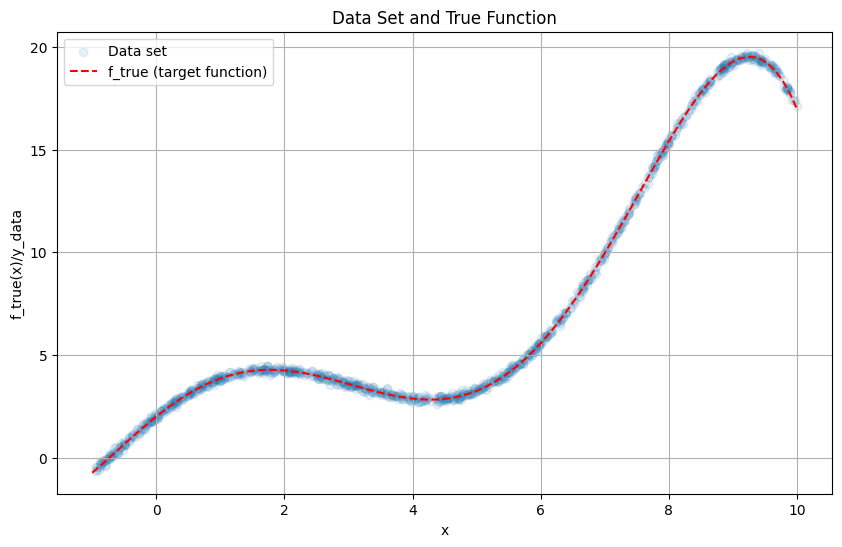

In [ ]:
# EXERCISE: Plot the data set and the true function (e.g. on a very fine grid).
plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, alpha=0.10,label="Data set")
plt.plot(x_plot,y_plot,"r--",label="f_true (target function)")
plt.title("Data Set and True Function")
plt.xlabel("x")
plt.ylabel("f_true(x)/y_data")
plt.legend()
plt.grid(True)
plt.show()

## Step 3: Neural network model

The neural network architecture is defined as follows. Notice that here we do not specify the values of the weights and biases. We only fix the number of layers, the dimension, and the activation functions.

In [ ]:
# Create a neural network with 2 hidden layers, each with 10 neurons and sigmoid activation
class NNModel(nn.Module):
    def __init__(self):
        super(NNModel, self).__init__()
        self.fc1 = nn.Linear(1, 10)  # First hidden layer with 10 neurons
        self.fc2 = nn.Linear(2,10) # Second hidden layer with 10 neurons
        self.fc3 = nn.Linear(3,1) # Output layer with 1 neuron
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation function

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.sigmoid(self.fc3(x))  # No activation on the output layer (regression)
        return x

We can print the model's details.

In [ ]:
# Create the model and print it
model = NNModel()
print(model)

NNModel(
  (fc1): Linear(in_features=1, out_features=10, bias=True)
  (fc2): Linear(in_features=2, out_features=10, bias=True)
  (fc3): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
from torchsummary import summary

print(summary(model, (1,)))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x10 and 2x10)

## Step 4: Training function

We define a function to train the model (i.e., to tune the parameters of the the parameterized function).

In [ ]:
# Train the neural network to minimize the MSE with the dataset using SGD optimizer
def train_nn(model, x_train, y_train, epochs=100, mb_size=100):
    # Convert numpy arrays to torch tensors
    x_train = torch.FloatTensor(x_train).unsqueeze(1)  # Shape (1000, 1)
    y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Shape (1000, 1)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # Training loop
    for epoch in range(epochs):
        epoch_loss = 0.0

        # Split the data into 10 mini-batches
        for i in range(10):  # 10 mini-batches
            # Sample mini-batch
            indices = np.random.choice(len(x_train), mb_size, replace=False)
            x_batch = x_train[indices]
            y_batch = y_train[indices]

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            y_pred = model(x_batch)

            # Compute loss (MSE)
            loss = criterion(y_pred, y_batch)

            # Backward pass and optimization step
            loss.backward()
            optimizer.step()

            # Accumulate loss for the epoch
            epoch_loss += loss.item()

        # Print average loss for each epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/10:.6f}')


## Step 5: Training

Then we call this function to perform the training.


In [ ]:
# Train the model
train_nn(model, x_data, y_data, epochs=100)

Epoch 1/100, Loss: 60.304744
Epoch 2/100, Loss: 38.458020
Epoch 3/100, Loss: 34.624282
Epoch 4/100, Loss: 34.102378
Epoch 5/100, Loss: 33.104657
Epoch 6/100, Loss: 29.953183
Epoch 7/100, Loss: 29.268642
Epoch 8/100, Loss: 28.812498
Epoch 9/100, Loss: 27.174407
Epoch 10/100, Loss: 25.634764
Epoch 11/100, Loss: 23.768022
Epoch 12/100, Loss: 21.960752
Epoch 13/100, Loss: 20.230370
Epoch 14/100, Loss: 18.274214
Epoch 15/100, Loss: 15.693738
Epoch 16/100, Loss: 13.666874
Epoch 17/100, Loss: 13.255159
Epoch 18/100, Loss: 11.500816
Epoch 19/100, Loss: 11.478126
Epoch 20/100, Loss: 9.446991
Epoch 21/100, Loss: 8.680906
Epoch 22/100, Loss: 8.842070
Epoch 23/100, Loss: 7.741917
Epoch 24/100, Loss: 7.921226
Epoch 25/100, Loss: 8.169078
Epoch 26/100, Loss: 9.882763
Epoch 27/100, Loss: 9.302855
Epoch 28/100, Loss: 5.986674
Epoch 29/100, Loss: 8.919334
Epoch 30/100, Loss: 11.463810
Epoch 31/100, Loss: 8.167004
Epoch 32/100, Loss: 12.407083
Epoch 33/100, Loss: 6.086048
Epoch 34/100, Loss: 6.031940
Ep

In [ ]:
# EXERCISE: Modify the code to print the value only every 5 epoch instead of every epoch.

## Step 6: Plotting the result

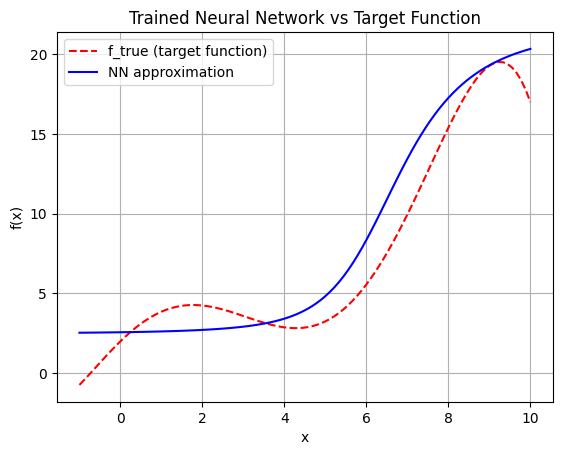

In [ ]:
# Plot the trained neural network function along with the target function
x_test = torch.FloatTensor(x_plot).unsqueeze(1)  # Convert test x values to tensor
y_nn = model(x_test).detach().numpy()  # Get neural network predictions and convert to numpy

# Plot the neural network's function and the true function
plt.plot(x_plot, y_plot, 'r--', label="f_true (target function)")  # True function in red dashed line
plt.plot(x_plot, y_nn, 'b-', label="NN approximation")  # NN approximation in blue line
plt.title("Trained Neural Network vs Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

## Warning: Overfitting

Let us try another example.

Epoch 1/100, Loss: 130.162339
Epoch 2/100, Loss: 66.043064
Epoch 3/100, Loss: 61.005092
Epoch 4/100, Loss: 59.455435
Epoch 5/100, Loss: 57.189033
Epoch 6/100, Loss: 54.320082
Epoch 7/100, Loss: 51.279145
Epoch 8/100, Loss: 47.736635
Epoch 9/100, Loss: 43.145809
Epoch 10/100, Loss: 37.285608
Epoch 11/100, Loss: 30.342922
Epoch 12/100, Loss: 23.033306
Epoch 13/100, Loss: 16.352708
Epoch 14/100, Loss: 11.026691
Epoch 15/100, Loss: 7.213591
Epoch 16/100, Loss: 4.665741
Epoch 17/100, Loss: 3.021556
Epoch 18/100, Loss: 1.972131
Epoch 19/100, Loss: 1.300493
Epoch 20/100, Loss: 0.866642
Epoch 21/100, Loss: 0.583140
Epoch 22/100, Loss: 0.395722
Epoch 23/100, Loss: 0.270494
Epoch 24/100, Loss: 0.186028
Epoch 25/100, Loss: 0.128596
Epoch 26/100, Loss: 0.089275
Epoch 27/100, Loss: 0.062199
Epoch 28/100, Loss: 0.043464
Epoch 29/100, Loss: 0.030447
Epoch 30/100, Loss: 0.021373
Epoch 31/100, Loss: 0.015029
Epoch 32/100, Loss: 0.010584
Epoch 33/100, Loss: 0.007462
Epoch 34/100, Loss: 0.005267
Epoch 35

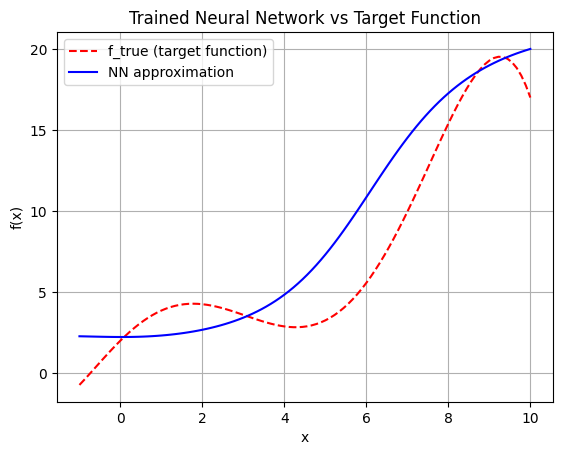

In [ ]:
# Create a dataset of points (x_i, y_i), where y_i = f_true(x_i) + noise
np.random.seed(42)  # For reproducibility
x_data = np.random.uniform(-1, 10, 2)
epsilon = np.random.normal(0, 0.1, 2)  # Gaussian noise with small std dev
y_data = f_true(x_data) + epsilon

# Model creation
model = NNModel()

# Train the model
train_nn(model, x_data, y_data, epochs=100, mb_size=2)

# Plot the trained neural network function along with the target function
x_test = torch.FloatTensor(x_plot).unsqueeze(1)  # Convert test x values to tensor
y_nn = model(x_test).detach().numpy()  # Get neural network predictions and convert to numpy

# Plot the neural network's function and the true function
plt.plot(x_plot, y_plot, 'r--', label="f_true (target function)")  # True function in red dashed line
plt.plot(x_plot, y_nn, 'b-', label="NN approximation")  # NN approximation in blue line
plt.title("Trained Neural Network vs Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

The loss is $0$ but... the neural network does not match the target function!

This is because we only measure the loss on the **training set**.

## Exercises

In [ ]:
# EXERCISE: Define a new (feedforward, fully connected) neural network class, different from the previous one.
# What are your degrees of freedom?

In [ ]:
# EXERCISE: Train a neural network based on your definition
# See if the result is better/worse (in terms of training loss? in terms of visual result?)

# Part 2: Robustness

Remember that there is **randomness**:
- in the data set
- in the initialization of the neural network
- in the mini-batch we sample at each iteration.

Trying to draw conclusions based on a single realization of the training is not meaningful. We need to make sure the results we obtain are **robust and reproducible**.

For this, we will repeat the experiment several times. But inspecting the realizations one by one is complex and not feasible for a large number of experiments. Let us look at the **average behavior** and the variance. We will focus on the performance of the loss.

Looking at the value of the loss during training is interesting, but what we care about if the performance of the neural netwokr ``in general'', not just on the training set. In other words, we want to make sure that, when the training loss is small, it is not because of overfitting. So we will use a **testing set**, generated independently of the training set.

## Modification 1: Training function with testing

In [ ]:
# New training function, taking as input a test set and possibly the seed index
def train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=100, lr=0.01, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    # Convert numpy arrays to torch tensors
    x_train = torch.FloatTensor(x_train).unsqueeze(1)  # Shape (n_points, 1)
    y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Shape (n_points, 1)
    x_test = torch.FloatTensor(x_test).unsqueeze(1)    # Test set
    y_test = torch.FloatTensor(y_test).unsqueeze(1)    # Test set

    # Define loss function and optimizer
    criterion = # TODO
    optimizer = # TODO

    # Store test loss at initialization and after each epoch
    test_losses = []

    # Initial evaluation on the testing set
    with torch.no_grad():
        y_pred_test = # TODO
        test_loss = # TODO
        test_losses.append(test_loss)

    # Training loop
    for epoch in range(epochs):
        # Split the data into 10 mini-batches (100 points per batch)
        for i in range(10):  # 10 mini-batches
            indices = np.random.choice(len(x_train), 100, replace=False)
            x_batch = x_train[indices]
            y_batch = y_train[indices]

            # Zero the gradients
            # TODO

            # Forward pass
            y_pred = # TODO

            # Compute loss (MSE)
            loss = # TODO

            # Backward pass and optimization step
            # TODO
            # TODO

        # Evaluate on the testing set at the end of each epoch
        with torch.no_grad():
            y_pred_test = # TODO
            test_loss = # TODO
            test_losses.append(test_loss)

    return test_losses


## Modification 2: Multiple realizations

We start with a fucntion to generate a data set. We will use it to generate the training set and the testing set.

In [ ]:
# A function to generate a data set of given size
def generate_dataset(n_points, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x_data = np.random.uniform(-1, 10, n_points)
    epsilon = np.random.normal(0, 0.1, n_points)  # Gaussian noise
    y_data = f_true(x_data) + epsilon
    return x_data, y_data

Then we perform the training several times.

In [ ]:
seeds = [1, 2, 3, 4, 5]  # List of seeds
epochs = 100


# Generate a training dataset of 1000 points and a testing dataset of 200 points
x_train, y_train = generate_dataset(1000, seed=42)
x_test, y_test = generate_dataset(200, seed=43)

# Store losses across runs
all_test_losses = []

for seed in seeds:
    print(f"Training with seed {seed}")
    # Create a new model for each run
    model = NNModel()

    # Train the model and store the test loss
    test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, seed=seed)
    all_test_losses.append(test_losses)

# Convert test losses to a numpy array of shape (num_seeds, epochs+1)
all_test_losses = np.array(all_test_losses)


Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5


From here, we can plot the evolution of the average testing loss during the training epochs.

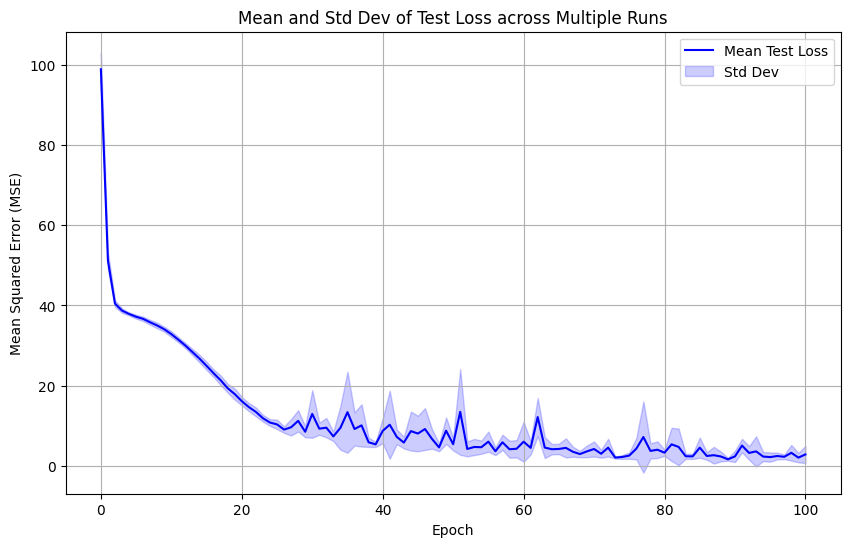

In [ ]:
# Compute mean and standard deviation of losses across runs
mean_losses = # TODO
std_losses = # TODO

# Plot the mean loss and the standard deviation as a shaded area
epochs_range = np.arange(epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, mean_losses, label='Mean Test Loss', color='blue')
plt.fill_between(epochs_range, mean_losses - std_losses, mean_losses + std_losses, color='blue', alpha=0.2, label='Std Dev')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

Sometimes, it is useful to use a logarithmic scale for the loss axis, to see better whether the loss keeps decaying when the values are much smaller than the initial one. However, the shaded area looks less nice.

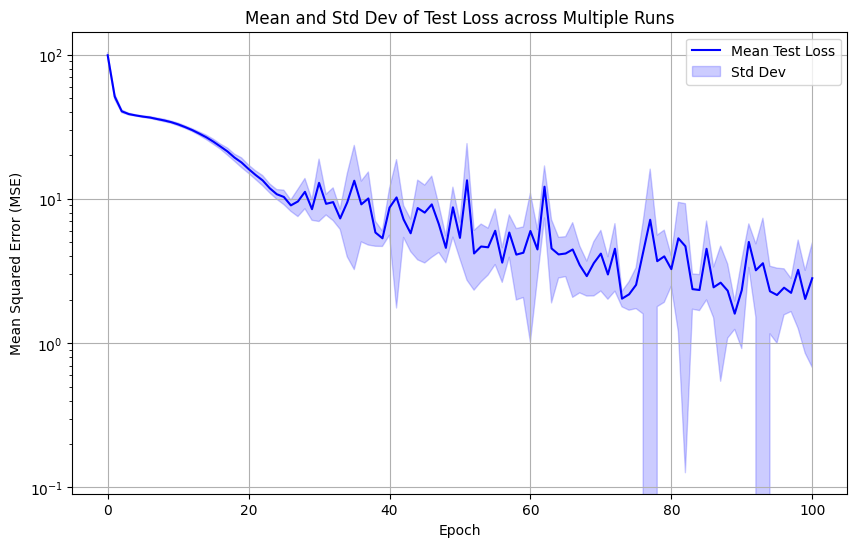

In [ ]:
plt.figure(figsize=(10, 6))
plt.semilogy(epochs_range, mean_losses, label='Mean Test Loss', color='blue')
plt.fill_between(epochs_range, mean_losses - std_losses, mean_losses + std_losses, color='blue', alpha=0.2, label='Std Dev')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

# Part 3: Improving the results

In this section we will try to get better results, i.e., to make the neural network fit better the function. To this end, we will **not change** the problem. We will change the hyperparameters. The main ones are:
- the NN architecture (larger width and/or depth)
- the learning rate and the mini-batch size
- the optimizer (variants of SGD such as Adam).

There is no perfect recipe for this. It is problem dependent and we generally need to run sweeps over hyperparameters, i.e., to try many different values and inspect the performance.

But by understanding the qualitative role of each hyperparameter can guide the search for better choices and can help to save a lot of time.

## Improvement 1: NN width

Let us try with a wider NN. We define a variable-width architecture and we will try various widths.

In [ ]:
# NN Model with variable width in the constructor
class NNModelW(nn.Module):
    def __init__(self, width):
        super(NNModelW, self).__init__()
        self.fc1 = nn.Linear(1, width)  # First hidden layer
        self.fc2 = nn.Linear(width, width)  # Second hidden layer
        self.fc3 = nn.Linear(width, 1)  # Output layer with 1 neuron
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation function

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.fc3(x)  # No activation on the output layer (regression)
        return x

In [ ]:
# EXERCISE: Create and print the model.

We can reuse our training function without any change! This is becauase it takes the model as an **input**. It does not depend on the exact architecture.

In [ ]:
seeds = np.arange(10)  # List of seeds
epochs = 100

# List of widths to try
widths = [10, 100, 200]

# Generate a training dataset of 1000 points and a testing dataset of 200 points
x_train, y_train = generate_dataset(1000, seed=42)
x_test, y_test = generate_dataset(200, seed=43)

# Store average losses and stddev across widths
mean_losses_w = []
std_losses_w = []

# For each widths, train as before for multiple seeds
for w in widths:
    print(f"Training with width {w}")

    # Store losses across runs
    all_test_losses = []

    for seed in seeds:
        print(f"Training with seed {seed}")
        # Create a new model for each run
        model = NNModelW(w)

        # Train the model and store the test loss
        test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, seed=seed)
        all_test_losses.append(test_losses)

    # Convert test losses to a numpy array of shape (num_seeds, epochs+1)
    all_test_losses = np.array(all_test_losses)

    # Compute mean and standard deviation
    mean_losses_w.append(np.mean(all_test_losses, axis=0))
    std_losses_w.append(np.std(all_test_losses, axis=0))



Training with width 10
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5
Training with seed 6
Training with seed 7
Training with seed 8
Training with seed 9
Training with width 100
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5
Training with seed 6
Training with seed 7
Training with seed 8
Training with seed 9
Training with width 200
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5
Training with seed 6
Training with seed 7
Training with seed 8
Training with seed 9


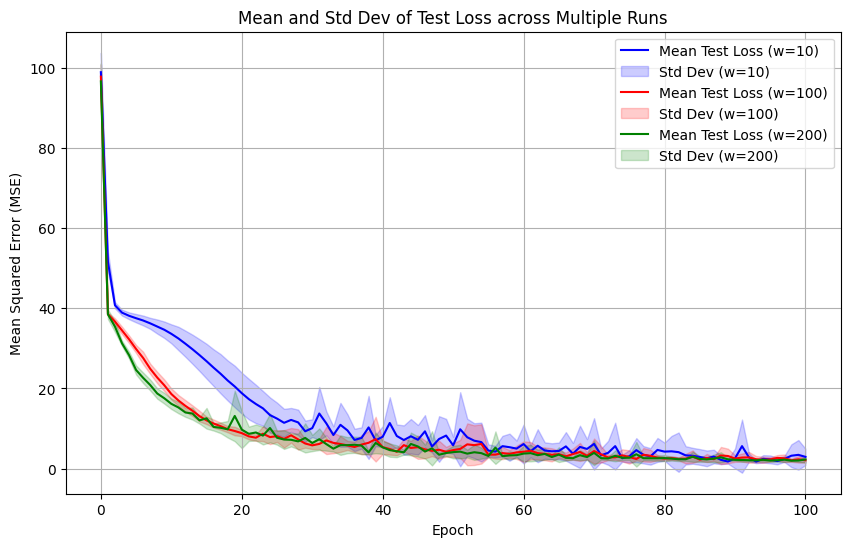

In [ ]:
# Plot the mean loss and the standard deviation as a shaded area
epochs_range = np.arange(epochs + 1)

colors = ['blue', 'red', 'green'] # should of the same length as the number of widths

plt.figure(figsize=(10, 6))
for i, w in enumerate(widths):
  plt.plot(epochs_range, mean_losses_w[i], label=f'Mean Test Loss (w={w})', color=colors[i])
  plt.fill_between(epochs_range, mean_losses_w[i] - std_losses_w[i], mean_losses_w[i] + std_losses_w[i], color=colors[i], alpha=0.2, label=f'Std Dev (w={w})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

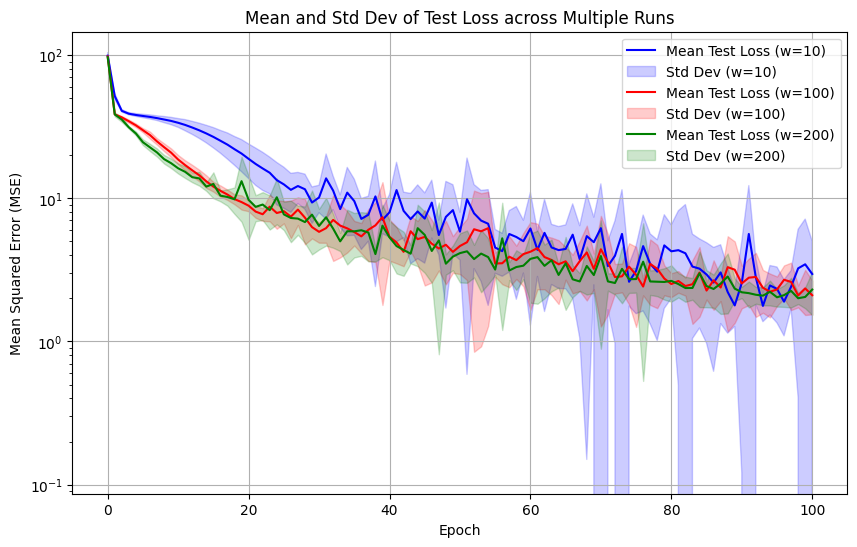

In [ ]:
# With semilog-y
plt.figure(figsize=(10, 6))
for i, w in enumerate(widths):
  plt.semilogy(epochs_range, mean_losses_w[i], label=f'Mean Test Loss (w={w})', color=colors[i])
  plt.fill_between(epochs_range, mean_losses_w[i] - std_losses_w[i], mean_losses_w[i] + std_losses_w[i], color=colors[i], alpha=0.2, label=f'Std Dev (w={w})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

## Improvement 2: NN depth

Let us try with a deeper NN.

In [ ]:
# NN Model with variable width in the constructor
class NNModelD(nn.Module):
    def __init__(self, width):
        super(NNModelD, self).__init__()
        self.fc1 = nn.Linear(1, width)  # First hidden layer
        self.fc2 = nn.Linear(width, width)  # Hidden layer
        self.fc3 = nn.Linear(width, width)  # Hidden layer
        self.fc4 = nn.Linear(width, 1)  # Output layer with 1 neuron
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation function

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        x = self.fc4(x)  # No activation on the output layer (regression)
        return x

In [ ]:
# Exercise: Create and print a model.

In [ ]:
seeds = np.arange(6)  # List of seeds
epochs = 1000

# Generate a training dataset of 1000 points and a testing dataset of 200 points
x_train, y_train = generate_dataset(1000, seed=42)
x_test, y_test = generate_dataset(200, seed=43)

# Store average losses and stddev across widths
mean_losses_d = []
std_losses_d = []


In [ ]:
# Training original model
print(f"Training original model")

# Store losses across runs
all_test_losses = []

for seed in seeds:
    print(f"Training with seed {seed}")
    # Create a new model for each run
    model = NNModel() # original model

    # Train the model and store the test loss
    test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, seed=seed)
    all_test_losses.append(test_losses)

# Convert test losses to a numpy array of shape (num_seeds, epochs+1)
all_test_losses = np.array(all_test_losses)

# Compute mean and standard deviation
mean_losses = np.mean(all_test_losses, axis=0)
std_losses = np.std(all_test_losses, axis=0)

Training original model
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5


In [ ]:
# Training deeper model
print(f"Training deeper model")

# Store losses across runs
all_test_losses_d = []

for seed in seeds:
    print(f"Training with seed {seed}")
    # Create a new model for each run
    model = NNModelD(10) # deeper model, with same width

    # Train the model and store the test loss
    test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, seed=seed)
    all_test_losses_d.append(test_losses)

# Convert test losses to a numpy array of shape (num_seeds, epochs+1)
all_test_losses_d = np.array(all_test_losses_d)

# Compute mean and standard deviation
mean_losses_d = np.mean(all_test_losses_d, axis=0)
std_losses_d = np.std(all_test_losses_d, axis=0)

Training deeper model
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5


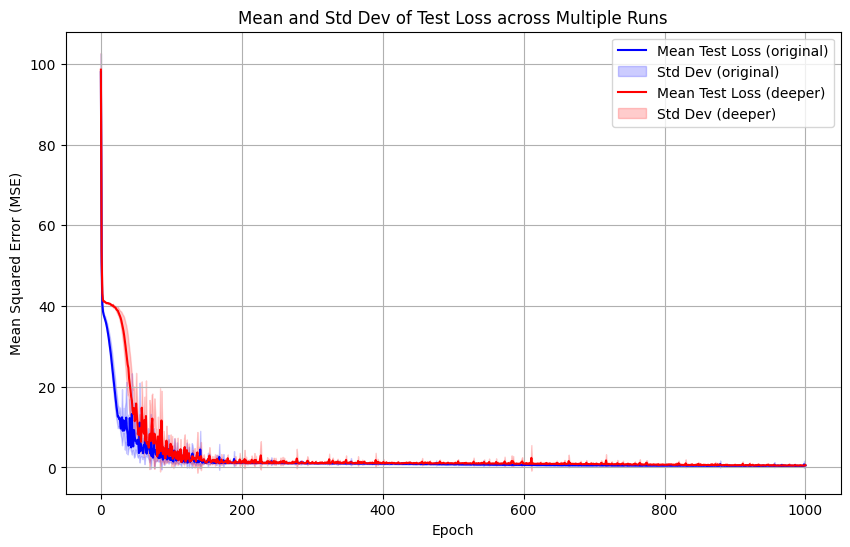

In [ ]:
# Plot the mean loss and the standard deviation as a shaded area
epochs_range = np.arange(epochs + 1)

colors = ['blue', 'red'] # should of the same length as the number of models

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, mean_losses, label='Mean Test Loss (original)', color=colors[0])
plt.fill_between(epochs_range, mean_losses - std_losses, mean_losses + std_losses, color=colors[0], alpha=0.2, label='Std Dev (original)')
plt.plot(epochs_range, mean_losses_d, label='Mean Test Loss (deeper)', color=colors[1])
plt.fill_between(epochs_range, mean_losses_d - std_losses_d, mean_losses_d + std_losses_d, color=colors[1], alpha=0.2, label='Std Dev (deeper)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

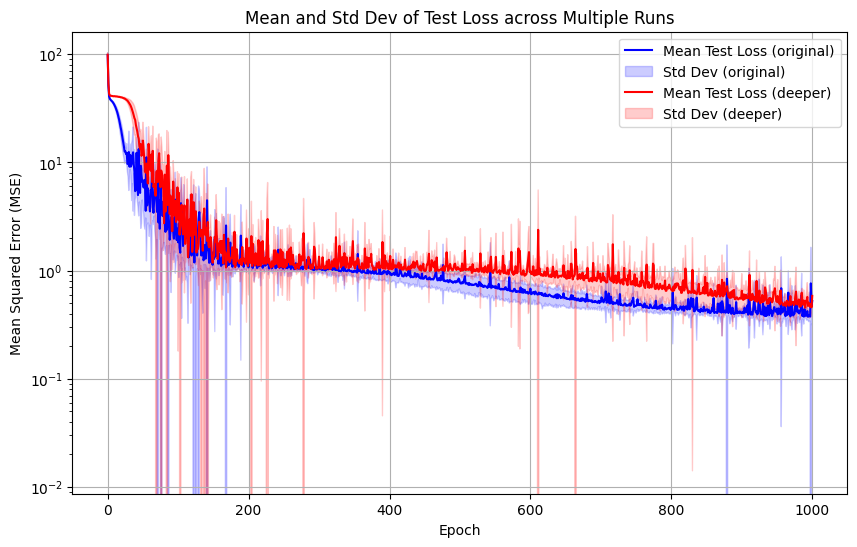

In [ ]:
plt.figure(figsize=(10, 6))
plt.semilogy(epochs_range, mean_losses, label='Mean Test Loss (original)', color=colors[0])
plt.fill_between(epochs_range, mean_losses - std_losses, mean_losses + std_losses, color=colors[0], alpha=0.2, label='Std Dev (original)')
plt.semilogy(epochs_range, mean_losses_d, label='Mean Test Loss (deeper)', color=colors[1])
plt.fill_between(epochs_range, mean_losses_d - std_losses_d, mean_losses_d + std_losses_d, color=colors[1], alpha=0.2, label='Std Dev (deeper)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

As a side remark, we observe that with more iterations, the original model's performance improves after some plateau. So using more iterations is useful in this case.

## Improvement 3: Learning rate and mini-batches

Let us try a smaller learning rate. Typically, a smaller learning rate means that the gradient descent will take more iterations to converge, but it will converge to a more accurate solution.

In [ ]:
seeds = np.arange(6)  # List of seeds
epochs = 1000

# Generate a training dataset of 1000 points and a testing dataset of 200 points
x_train, y_train = generate_dataset(1000, seed=42)
x_test, y_test = generate_dataset(200, seed=43)

# Store average losses and stddev across widths
mean_losses_d = []
std_losses_d = []

In [ ]:
# Training original model
print(f"Training original model")

# Store losses across runs
all_test_losses = []

for seed in seeds:
    print(f"Training with seed {seed}")
    # Create a new model for each run
    model = NNModel() # original model

    # Train the model and store the test loss
    test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, seed=seed)
    all_test_losses.append(test_losses)

# Convert test losses to a numpy array of shape (num_seeds, epochs+1)
all_test_losses = np.array(all_test_losses)

# Compute mean and standard deviation
mean_losses = np.mean(all_test_losses, axis=0)
std_losses = np.std(all_test_losses, axis=0)

Training original model
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5


In [ ]:
# Training with smaller learning rate
print(f"Training original model with smaller learning rate")

# Learning rate
small_lr = 0.001

# Store losses across runs
all_test_losses_smalllr = []

for seed in seeds:
    print(f"Training with seed {seed}")
    # Create a new model for each run
    model = NNModel() # original model

    # Train the model and store the test loss
    test_losses = train_nn_with_test(model, x_train, y_train, x_test, y_test, epochs=epochs, lr=small_lr, seed=seed)
    all_test_losses_smalllr.append(test_losses)

# Convert test losses to a numpy array of shape (num_seeds, epochs+1)
all_test_losses_smalllr = np.array(all_test_losses_smalllr)

# Compute mean and standard deviation
mean_losses_smalllr = np.mean(all_test_losses_smalllr, axis=0)
std_losses_smalllr = np.std(all_test_losses_smalllr, axis=0)

Training original model with smaller learning rate
Training with seed 0
Training with seed 1
Training with seed 2
Training with seed 3
Training with seed 4
Training with seed 5


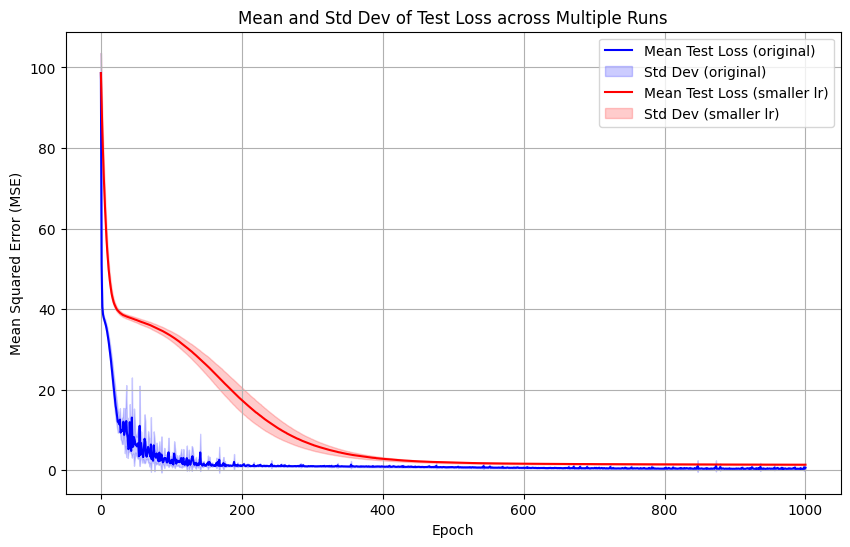

In [ ]:
# Plot the mean loss and the standard deviation as a shaded area
epochs_range = np.arange(epochs + 1)

colors = ['blue', 'red'] # should of the same length as the number of models

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, mean_losses, label='Mean Test Loss (original)', color=colors[0])
plt.fill_between(epochs_range, mean_losses - std_losses, mean_losses + std_losses, color=colors[0], alpha=0.2, label='Std Dev (original)')
plt.plot(epochs_range, mean_losses_smalllr, label='Mean Test Loss (smaller lr)', color=colors[1])
plt.fill_between(epochs_range, mean_losses_smalllr - std_losses_smalllr, mean_losses_smalllr + std_losses_smalllr, color=colors[1], alpha=0.2, label='Std Dev (smaller lr)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean and Std Dev of Test Loss across Multiple Runs')
plt.legend()
plt.grid(True)
plt.show()

## Other ideas?